In [1]:
import os
import glob
import json


In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import model_config as config
from model_stats import Statistics
from model_compile_data import _return_all_mfpt_trajectories


param_id = "param_set_WT_NANOG_OE"
param_ids = ["param_set_WT_NANOG_OE", "param_set_WT_DIMER", "param_set_W10A_MONOMER"]
for param in param_ids:
    _return_all_mfpt_trajectories(param, 1000, 10)



Processed param_set_WT_NANOG_OE (23775 runs)

Concatenating master dataset...

SUCCESS! Master dataset saved to:
 -> J:/test/CASES\param_set_WT_NANOG_OE_all_mfpt_histogram_data.parquet
Total Rows (Individual Runs): 23775
Total Columns (Features): 5
Processed param_set_WT_DIMER (8558 runs)

Concatenating master dataset...

SUCCESS! Master dataset saved to:
 -> J:/test/CASES\param_set_WT_DIMER_all_mfpt_histogram_data.parquet
Total Rows (Individual Runs): 8558
Total Columns (Features): 5
Processed param_set_W10A_MONOMER (22411 runs)

Concatenating master dataset...

SUCCESS! Master dataset saved to:
 -> J:/test/CASES\param_set_W10A_MONOMER_all_mfpt_histogram_data.parquet
Total Rows (Individual Runs): 22411
Total Columns (Features): 5


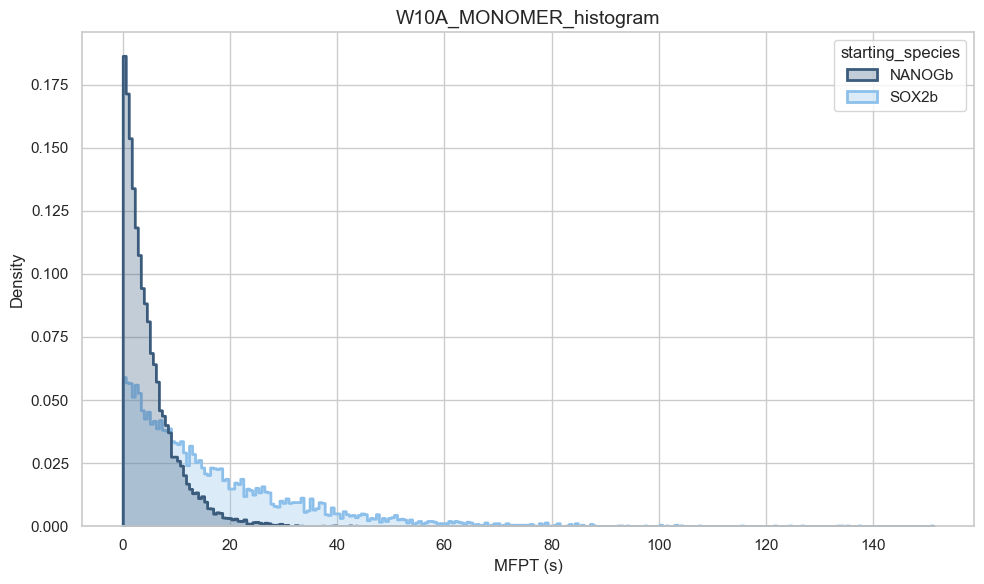

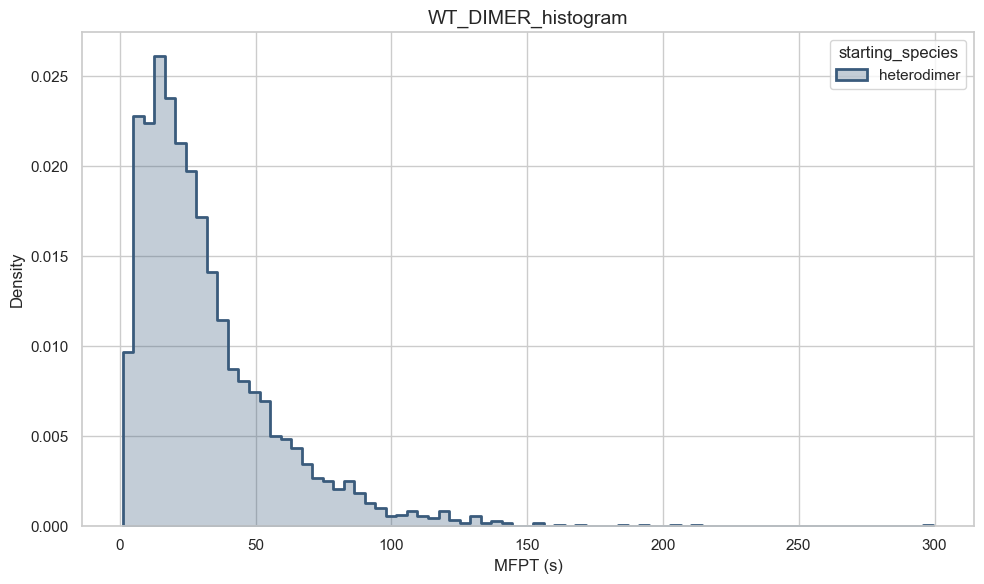

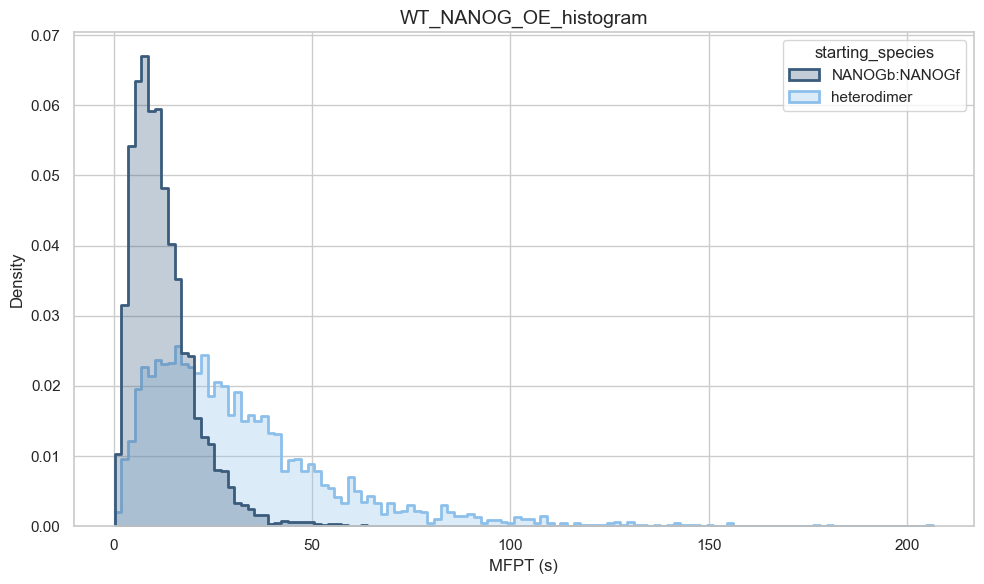

: 

In [ ]:
def plot_mfpt_histogram(
    file_path: str, 
    out_file_name: str, 
    plot_title: str,
    exclude_species: list = None,
    colors: list = None,
    require_multistep: bool = False
):
    if exclude_species is None:
        exclude_species = ["SOX2b:NANOGf", "NANOGb:SOX2f"]
    if colors is None:
        colors = ["#3A5B7C", "#8CC0EB", "#F0F0F0", "#EAC396", "#DAA464"]

    df = pl.read_parquet(file_path)
    df_pd = df.to_pandas()
    
    target_col = "mature_lifespan_s" if require_multistep else "transient_lifespan_s"
    
    df_pd = df_pd.dropna(subset=[target_col])
    df_pd = df_pd[df_pd[target_col] > 0]

    for species_to_drop in exclude_species:
        df_pd = df_pd[df_pd["starting_species"] != species_to_drop]

    if df_pd.empty:
        return

    sns.set_theme(style="whitegrid")
    sns.set_palette(sns.color_palette(colors))

    plt.figure(figsize=(10, 6))

    sns.histplot(
        data=df_pd,
        x=target_col,
        hue="starting_species",
        element="step", 
        stat="density",
        common_norm=False,    
        alpha=0.3,            
        linewidth=2,
    )

    plt.title(plot_title, fontsize=14)
    plt.xlabel("MFPT (s)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.tight_layout()
    
    plt.savefig(out_file_name, dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    file_path1 = r"J:/test/CASES\param_set_W10A_MONOMER_all_mfpt_histogram_data.parquet"
    file_path2 = r"J:/test/CASES\param_set_WT_DIMER_all_mfpt_histogram_data.parquet"
    file_path3 = r"J:/test/CASES\param_set_WT_NANOG_OE_all_mfpt_histogram_data.parquet"

    plot_mfpt_histogram(file_path1, "W10A_MONOMER.png", plot_title="W10A_MONOMER_histogram", require_multistep=False)
    plot_mfpt_histogram(file_path2, "WT_DIMER.png", plot_title="WT_DIMER_histogram", require_multistep=True)
    plot_mfpt_histogram(file_path3, "WT_NANOG_OE.png", plot_title="WT_NANOG_OE_histogram", require_multistep=True)